# SINGLE-CELL END-TO-END ABC PIPELINE — GSE161626

>>> Workspace: /content/ABC_DOI
>>> Downloading GSE161626 (slow step, ~20–40 min)…
>>> K27ac bigWigs: 48
>>> Samples per group:
 {'24h': 12, '48h': 12, '7d': 12, 'VEH': 12}


Peak union:   0%|          | 0/24 [00:00<?, ?it/s]

>>> Consensus peaks: 68300


Quantify signal:   0%|          | 0/48 [00:00<?, ?it/s]

>>> Signal matrix: (68300, 48)
>>> Significant 7d-vs-VEH enhancers: 14438
>>> Cluster profiles:
           VEH   24h   48h    7d
cluster                        
0       -1.41  0.57  0.52  0.32
1        1.10  0.09 -0.02 -1.17
2       -0.28 -0.59 -0.52  1.39
3        0.30  0.61  0.50 -1.41
4        1.39 -0.52 -0.55 -0.31
5       -1.14 -0.09  0.12  1.12
>>> Persistent UP clusters [0, 5], DOWN [1, 4]; total persistent enhancers: 9889
>>> Protein-coding genes: 21674


ABC scoring:   0%|          | 0/21674 [00:00<?, ?it/s]

>>> ABC predictions above threshold: 471819
>>> Final enhancer-gene pairs: 471819 | unique target genes: 21516
>>> RNA TXT not found in TAR — skipped


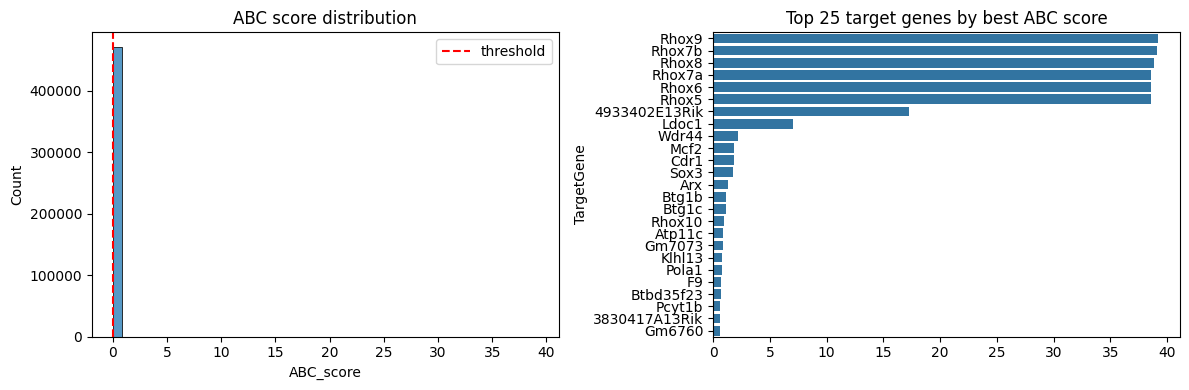

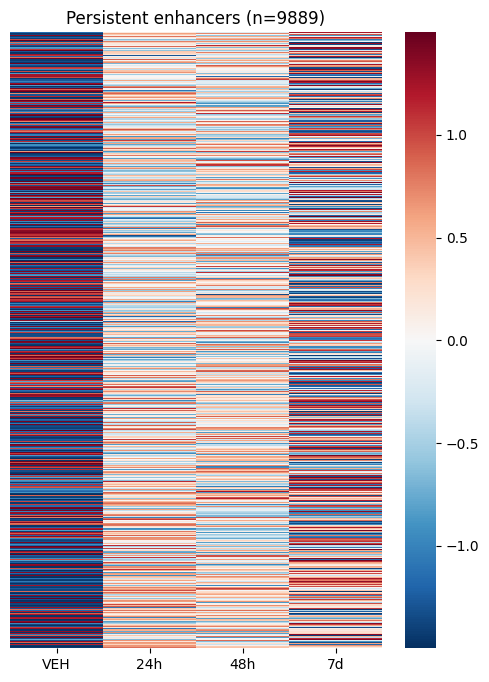


=== DONE ===
Outputs in: /content/ABC_DOI/ABC_output


CompletedProcess(args='ls -lh ABC_output/', returncode=0)

In [ ]:
# =====================================================================
# SINGLE-CELL END-TO-END ABC PIPELINE — GSE161626 (DOI mouse H3K27ac)
# Persistent enhancers (VEH→24h→48h→7d) linked to genes via ABC model
# =====================================================================

# ---------- 0. Install deps ----------
import subprocess, sys
subprocess.run("pip -q install pyBigWig pyranges gtfparse statsmodels tqdm seaborn",
               shell=True, check=False)
subprocess.run("apt-get -qq install -y wget > /dev/null", shell=True, check=False)

import os, re, glob, warnings
import numpy as np, pandas as pd
import pyBigWig, pyranges as pr
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import quantile_transform
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

# ---------- 1. Workspace ----------
WORK = "/content/ABC_DOI"
os.makedirs(WORK, exist_ok=True); os.chdir(WORK)
for d in ["data/bw","data/rna","abc_inputs","peaks","ABC_output"]:
    os.makedirs(d, exist_ok=True)
print(">>> Workspace:", WORK)

# ---------- 2. Download GSE161626 bigWigs ----------
TAR = "data/GSE161626_RAW.tar"
if not os.path.exists(TAR):
    print(">>> Downloading GSE161626 (slow step, ~20–40 min)…")
    subprocess.run(
        f'wget -q -O {TAR} '
        f'"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE161626&format=file"',
        shell=True, check=True)

subprocess.run(f"tar -tf {TAR} | grep -i K27ac | grep -Ei '\\.bw$|\\.bigwig$' "
               f"> data/bw_list.txt", shell=True)
subprocess.run(f"tar -xf {TAR} -C data/bw/ -T data/bw_list.txt", shell=True)
print(">>> K27ac bigWigs:", len(os.listdir("data/bw")))

# ---------- 3. Sample sheet ----------
rows = []
for f in sorted(glob.glob("data/bw/*.bw")):
    m = re.search(r"_(VEH|24h|48h|7d)(\d+)-(\d+)-K27ac", os.path.basename(f))
    if m:
        rows.append({"file":f, "group":m.group(1),
                     "mouse":int(m.group(2)), "rep":int(m.group(3))})
samples = pd.DataFrame(rows).sort_values(["group","mouse","rep"]).reset_index(drop=True)
print(">>> Samples per group:\n", samples.groupby("group").size().to_dict())

# ---------- 4. Consensus peak set from bigWig top-bins ----------
CHROMS = ["chr"+c for c in list(map(str,range(1,20)))+["X"]]

def top_bins(bw_path, bin_size=1000, top_pct=2.0):
    bw = pyBigWig.open(bw_path); out=[]
    for chrom in CHROMS:
        if chrom not in bw.chroms(): continue
        L = bw.chroms()[chrom]; nbins = L//bin_size
        vals = np.nan_to_num(bw.values(chrom, 0, nbins*bin_size, numpy=True))
        vals = vals.reshape(nbins, bin_size).mean(axis=1)
        if vals.max() == 0: continue
        cut = np.percentile(vals, 100-top_pct)
        idx = np.where(vals > cut)[0]
        out.extend((chrom, i*bin_size, (i+1)*bin_size) for i in idx)
    bw.close(); return out

if not os.path.exists("peaks/consensus.bed"):
    union_records = []
    for f in tqdm(samples.drop_duplicates(["group","mouse"]).file.tolist(),
                  desc="Peak union"):
        union_records.extend(top_bins(f))
    peaks = pr.PyRanges(pd.DataFrame(union_records,
                      columns=["Chromosome","Start","End"])).merge(slack=500)
    peaks = peaks[peaks.lengths() >= 500]
    peak_df = peaks.df.reset_index(drop=True)
    peak_df.to_csv("peaks/consensus.bed", sep="\t", header=False, index=False)
else:
    peak_df = pd.read_csv("peaks/consensus.bed", sep="\t", header=None,
                          names=["Chromosome","Start","End"])
peak_ids = [f"{c}:{s}-{e}" for c,s,e in zip(peak_df.Chromosome,
                                            peak_df.Start, peak_df.End)]
print(">>> Consensus peaks:", len(peak_df))

# ---------- 5. Quantify H3K27ac per peak per sample  (FAST, vectorized) ----------
# Build per-chromosome peak index arrays once
peak_df = peak_df.reset_index(drop=True)
peaks_by_chr = {c: g for c, g in peak_df.groupby("Chromosome")}

M = np.zeros((len(peak_df), len(samples)), dtype=np.float32)
for j in tqdm(range(len(samples)), desc="Quantify signal"):
    row = samples.iloc[j]                       # <-- FIX: was row[1].file
    bw = pyBigWig.open(row.file)
    chrom_sizes = bw.chroms()
    for chrom, gdf in peaks_by_chr.items():
        if chrom not in chrom_sizes: continue
        L = chrom_sizes[chrom]
        # one array per chromosome instead of 1000s of stats() calls
        arr = np.nan_to_num(bw.values(chrom, 0, L, numpy=True))
        starts = gdf.Start.values.astype(int)
        ends   = np.minimum(gdf.End.values.astype(int), L)
        idxs   = gdf.index.values
        for i, s, e in zip(idxs, starts, ends):
            if e > s:
                M[i, j] = arr[s:e].mean()
    bw.close()

cols = [f"{r.group}_m{r.mouse}_r{r.rep}" for _, r in samples.iterrows()]
M = pd.DataFrame(M, index=peak_ids, columns=cols)
M.to_csv("peaks/signal_matrix.tsv.gz", sep="\t")
print(">>> Signal matrix:", M.shape)

# ---------- 6. Normalize + 7d vs VEH differential ----------
logM = np.log2(M + 1)
qn = pd.DataFrame(quantile_transform(logM.values, axis=0,
                                     output_distribution="normal"),
                  index=M.index, columns=M.columns)
veh = [c for c in qn.columns if c.startswith("VEH")]
d24 = [c for c in qn.columns if c.startswith("24h")]
d48 = [c for c in qn.columns if c.startswith("48h")]
d7  = [c for c in qn.columns if c.startswith("7d")]
t7, p7 = stats.ttest_ind(qn[d7].values, qn[veh].values, axis=1)
lfc7 = qn[d7].mean(1) - qn[veh].mean(1)
fdr7 = multipletests(np.nan_to_num(p7, nan=1.0), method="fdr_bh")[1]
de = pd.DataFrame({"lfc_7d":lfc7.values, "p_7d":p7, "fdr_7d":fdr7}, index=qn.index)
sig = de[(de.fdr_7d < 0.05) & (de.lfc_7d.abs() > 0.25)]
de.to_csv("peaks/diff_7d_vs_VEH.tsv.gz", sep="\t")
print(">>> Significant 7d-vs-VEH enhancers:", len(sig))

# ---------- 7. Cluster timecourse → persistent enhancers ----------
means = pd.DataFrame({"VEH":qn[veh].mean(1), "24h":qn[d24].mean(1),
                      "48h":qn[d48].mean(1), "7d":qn[d7].mean(1)}).loc[sig.index]
Z = means.sub(means.mean(1), axis=0).div(means.std(1).replace(0,1), axis=0)
km = KMeans(n_clusters=6, random_state=0, n_init=20).fit(Z.values)
Z["cluster"] = km.labels_
profile = Z.groupby("cluster")[["VEH","24h","48h","7d"]].mean()
print(">>> Cluster profiles:\n", profile.round(2))

p_up = profile[(profile["24h"]>profile["VEH"]) & (profile["48h"]>profile["VEH"]) &
               (profile["7d"]>profile["VEH"]) & (profile["7d"]>0.3)].index.tolist()
p_dn = profile[(profile["24h"]<profile["VEH"]) & (profile["48h"]<profile["VEH"]) &
               (profile["7d"]<profile["VEH"]) & (profile["7d"]<-0.3)].index.tolist()
persistent_idx = Z[Z.cluster.isin(p_up+p_dn)].index
print(f">>> Persistent UP clusters {p_up}, DOWN {p_dn}; "
      f"total persistent enhancers: {len(persistent_idx)}")

pers_df = peak_df.copy()
pers_df.index = peak_ids
pers_df = pers_df.loc[persistent_idx].copy()
pers_df["direction"] = ["UP" if c in p_up else "DOWN"
                        for c in Z.loc[persistent_idx,"cluster"]]
pers_df["mean_7d_signal"] = means.loc[persistent_idx,"7d"].values
pers_df.to_csv("peaks/persistent_enhancers.bed", sep="\t", header=False,
               index=False, columns=["Chromosome","Start","End",
                                     "direction","mean_7d_signal"])

# ---------- 8. GENCODE vM25 TSS table  (URL confirmed from your listing) ----------
GTF = "abc_inputs/gencode.vM25.annotation.gtf.gz"
if not os.path.exists(GTF):
    subprocess.run(f"wget -q -O {GTF} "
        "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/"
        "release_M25/gencode.vM25.annotation.gtf.gz", shell=True, check=True)
from gtfparse import read_gtf
gtf = read_gtf(GTF)
gtf = gtf.to_pandas() if hasattr(gtf, "to_pandas") else gtf
genes = gtf[(gtf["feature"]=="gene") & (gtf["gene_type"]=="protein_coding")].copy()
genes = genes[genes["seqname"].isin(CHROMS)].copy()
genes["tss"] = np.where(genes.strand=="+", genes.start, genes.end)
tss = genes[["seqname","tss","gene_name","strand","gene_id"]].rename(
        columns={"seqname":"Chromosome"})
print(">>> Protein-coding genes:", len(tss))

# ---------- 9. Activity per persistent enhancer (mean 7d signal) ----------
act = M.loc[persistent_idx, d7].mean(axis=1).rename("activity").reset_index()
act.columns = ["peak_id","activity"]
act["Chromosome"] = act.peak_id.str.split(":").str[0]
act["Start"] = act.peak_id.str.split(":").str[1].str.split("-").str[0].astype(int)
act["End"]   = act.peak_id.str.split(":").str[1].str.split("-").str[1].astype(int)

# ---------- 10. ABC power-law contact + scoring ----------
GAMMA, SCALE, PSEUDO = 1.024, 5.9, 1.0
def contact(d):
    d = np.maximum(d, 1000)
    return np.exp(SCALE)*np.power(d, -GAMMA) + PSEUDO

WINDOW, THR = 5_000_000, 0.02
enh_by_chr = {c:g.reset_index(drop=True) for c,g in act.groupby("Chromosome")}
preds = []
for _, gene in tqdm(tss.iterrows(), total=len(tss), desc="ABC scoring"):
    if gene.Chromosome not in enh_by_chr: continue
    E = enh_by_chr[gene.Chromosome]
    mid = (E.Start + E.End)//2
    dist = np.abs(mid - gene.tss)
    mask = dist <= WINDOW
    if not mask.any(): continue
    sub = E.loc[mask].copy()
    sub["distance"] = dist[mask].values
    sub["contact"]  = contact(sub.distance.values)
    sub["AxC"]      = sub.activity * sub.contact
    denom = sub.AxC.sum()
    if denom <= 0: continue
    sub["ABC_score"] = sub.AxC / denom
    keep = sub[sub.ABC_score > THR].copy()
    if len(keep)==0: continue
    keep["TargetGene"]   = gene.gene_name
    keep["TargetGeneID"] = gene.gene_id
    keep["TargetTSS"]    = gene.tss
    preds.append(keep)
ABC = pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()
print(">>> ABC predictions above threshold:", len(ABC))

# ---------- 11. Annotate & save final predictions ----------
if len(ABC):
    dmap = pers_df.set_index(pers_df.Chromosome+":"+pers_df.Start.astype(str)+
                             "-"+pers_df.End.astype(str))[["direction","mean_7d_signal"]]
    ABC["direction"]      = ABC.peak_id.map(dmap.direction.to_dict())
    ABC["mean_7d_signal"] = ABC.peak_id.map(dmap.mean_7d_signal.to_dict())
    ABC["lfc_7d_vs_VEH"]  = ABC.peak_id.map(de.lfc_7d.to_dict())
    ABC["fdr_7d_vs_VEH"]  = ABC.peak_id.map(de.fdr_7d.to_dict())
    final = ABC.sort_values("ABC_score", ascending=False)
    final.to_csv("ABC_output/EnhancerPredictions_persistent_7d.tsv.gz",
                 sep="\t", index=False)
    print(">>> Final enhancer-gene pairs:", len(final),
          "| unique target genes:", final.TargetGene.nunique())
else:
    final = pd.DataFrame()

# ---------- 12. RNA-seq cross-check ----------
subprocess.run(f"tar -tf {TAR} | grep -i RNA | grep -i '\\.txt' "
               f"> data/rna_list.txt", shell=True)
subprocess.run(f"tar -xf {TAR} -C data/rna/ -T data/rna_list.txt", shell=True)
rna_files = sorted(glob.glob("data/rna/*.txt*"))
Egrp = None
if rna_files:
    series=[]
    for fp in rna_files:
        try:
            df = pd.read_csv(fp, sep="\t", comment="#")
            gc = [c for c in df.columns if "gene" in c.lower() or "name" in c.lower()]
            vc = [c for c in df.columns if any(k in c.lower()
                  for k in ["tpm","fpkm","count","expr"])]
            if gc and vc:
                series.append(df.set_index(gc[0])[vc[0]].rename(os.path.basename(fp)))
        except Exception: pass
    if series:
        E = pd.concat(series, axis=1).fillna(0)
        def grp(c):
            m = re.search(r"(VEH|24h|48h|7d)\d+-\d+-RNA", c)
            return m.group(1) if m else None
        gmap = {c:grp(c) for c in E.columns}
        Egrp = pd.DataFrame({g: E.loc[:, [c for c,v in gmap.items() if v==g]].mean(1)
                             for g in ["VEH","24h","48h","7d"]
                             if any(v==g for v in gmap.values())})
        if "VEH" in Egrp.columns and "7d" in Egrp.columns:
            Egrp["log2FC_7d_vs_VEH"] = np.log2((Egrp["7d"]+1)/(Egrp["VEH"]+1))
            Egrp.to_csv("ABC_output/RNA_means.tsv.gz", sep="\t")
            if len(final):
                matched = Egrp.loc[Egrp.index.isin(final.TargetGene.unique())]
                print(f">>> ABC targets with RNA data: {len(matched)}")
                print(f"    mean |log2FC| ABC targets: "
                      f"{matched.log2FC_7d_vs_VEH.abs().mean():.3f}")
                print(f"    mean |log2FC| all genes : "
                      f"{Egrp.log2FC_7d_vs_VEH.abs().mean():.3f}")
print(">>> RNA validation done" if Egrp is not None else
      ">>> RNA TXT not found in TAR — skipped")

# ---------- 13. Plots ----------
if len(final):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(final.ABC_score, bins=50, ax=ax[0])
    ax[0].axvline(0.02, color="red", ls="--", label="threshold")
    ax[0].set_title("ABC score distribution"); ax[0].legend()
    top = final.groupby("TargetGene").ABC_score.max().sort_values(ascending=False).head(25)
    sns.barplot(x=top.values, y=top.index, ax=ax[1])
    ax[1].set_title("Top 25 target genes by best ABC score")
    plt.tight_layout(); plt.savefig("ABC_output/summary.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6,8))
sns.heatmap(Z.loc[persistent_idx, ["VEH","24h","48h","7d"]],
            cmap="RdBu_r", center=0, yticklabels=False, ax=ax)
ax.set_title(f"Persistent enhancers (n={len(persistent_idx)})")
plt.savefig("ABC_output/persistent_heatmap.png", dpi=150); plt.show()

print("\n=== DONE ===")
print("Outputs in:", os.path.abspath("ABC_output"))
subprocess.run("ls -lh ABC_output/", shell=True)

# Post-hoc


In [ ]:
%%bash

zcat ABC_output/EnhancerPredictions_persistent_7d.tsv.gz \
  | awk -F'\t' 'NR>1 {print $X}' \
  | sort -u > persistent_genes.txt

In [ ]:
%%bash

# Better filtering (adjust the number if needed)
awk '$2 > 0.05' /content/ABC_DOI/persistent_genes.txt | \
sort -k1,1 -k2,2nr | \
awk '!seen[$1]++' | \
awk '{print $10}' | sort | uniq > final_gene_list_clean.txt

wc -l final_gene_list_clean.txt
head -20 final_gene_list_clean.txt

4674 final_gene_list_clean.txt
0610040J01Rik
1110002E22Rik
1110012L19Rik
1110025L11Rik
1110032A03Rik
1110032F04Rik
1110051M20Rik
1110059E24Rik
1520401A03Rik
1600014C23Rik
1700003H04Rik
1700008P02Rik
1700013F07Rik
1700013G24Rik
1700014D04Rik
1700015G11Rik
1700017N19Rik
1700019A02Rik
1700019D03Rik
1700020N01Rik


### Turn to protein coding genes

In [ ]:
%%bash

# 1. Download the official mouse protein-coding gene list (one time only)
wget -q https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M32/gencode.vM32.primary_assembly.annotation.gtf.gz

# 2. Extract protein-coding gene names
zcat gencode.vM32.primary_assembly.annotation.gtf.gz | \
awk '$3 == "gene" && /gene_type "protein_coding"/' | \
sed 's/.*gene_name "//;s/".*//' | sort | uniq > protein_coding_genes_mm10.txt

# 3. Filter your gene list to keep only protein-coding genes
grep -Fxf protein_coding_genes_mm10.txt final_gene_list_clean.txt > final_gene_list_protein_coding.txt

# 4. Check the result
wc -l final_gene_list_protein_coding.txt
head -15 final_gene_list_protein_coding.txt

4449 final_gene_list_protein_coding.txt
0610040J01Rik
1110002E22Rik
1110025L11Rik
1110032A03Rik
1110032F04Rik
1110059E24Rik
1520401A03Rik
1600014C23Rik
1700003H04Rik
1700013G24Rik
1700014D04Rik
1700015G11Rik
1700017N19Rik
1700019A02Rik
1700019D03Rik


In [ ]:
%%bash

grep -v "Rik" final_gene_list_protein_coding.txt > final_gene_list_final.txt

# Check the result
wc -l final_gene_list_final.txt
head -15 final_gene_list_final.txt

4362 final_gene_list_final.txt
A1bg
A1cf
A2m
A4gnt
Aadacl4fm5
Aanat
Aar2
Aard
Aasdh
Aass
Aatf
Abat
Abca15
Abca3
Abca4


In [ ]:
%%bash

# Create GMT with UPPERCASE genes (for human TWAS)
echo -e "Persistent_Enhancer_Targets\tPsychedelic-induced persistent enhancers (mouse 7-day DOI)\t$(cat final_gene_list_final.txt | tr '[:lower:]' '[:upper:]' | tr '\n' '\t')" > Persistent_Enhancer_Targets_Upper.gmt

wc -l Persistent_Enhancer_Targets_Upper.gmt
head -c 250 Persistent_Enhancer_Targets_Upper.gmt

1 Persistent_Enhancer_Targets_Upper.gmt
Persistent_Enhancer_Targets	Psychedelic-induced persistent enhancers (mouse 7-day DOI)	A1BG	A1CF	A2M	A4GNT	AADACL4FM5	AANAT	AAR2	AARD	AASDH	AASS	AATF	ABAT	ABCA15	ABCA3	ABCA4	ABCA6	ABCA8B	ABCB10	ABCB11	ABCB1A	ABCC1	ABCC2	ABCC8	ABCD2	ABCD3	ABCF2	ABCG2	

# Downstream Analysis

In [ ]:
# -*- coding: utf-8 -*-
"""
=====================================================================
ABC DOWNSTREAM ANALYSIS — GSE161626  (DOI psychedelic, mouse H3K27ac)
Persistent enhancer targets, 7-day post-DOI. Direction-aware.

Consumes (from the ABC pipeline, any that exist):
  ABC_output/EnhancerPredictions_persistent_7d.tsv.gz
        cols: peak_id, activity, ABC_score, TargetGene, direction,
              mean_7d_signal, lfc_7d_vs_VEH, fdr_7d_vs_VEH, ...
  final_gene_list_final.txt                  (clean mouse symbols)
  Persistent_Enhancer_Targets_Upper.gmt      (UPPER human-style, optional)
  ABC_output/RNA_means.tsv.gz                (RNA VEH/24h/48h/7d + log2FC)

Produces (in DOWNSTREAM/):
  enrichr/{ALL,UP,DOWN}/*    ORA across GO/KEGG/Reactome/MP/TF libs
  gsea_prerank/*             ranked GSEA on ABC score
  functional_categories.tsv  data-driven gene buckets (neuro themes)
  string_network.tsv, string_hubs.tsv
  rna_integration.tsv        ABC-target vs background RNA response
  figures/*.png              barplots, dotplots, hubs, RNA, heatmap-style
  SUMMARY.txt                <-- consolidated, all significant results
  run_log.txt                raw run log
=====================================================================
"""

# ---------- 0. Deps ----------
import subprocess, sys
subprocess.run("pip -q install gseapy requests adjustText", shell=True, check=False)

import os, re, gzip, glob, json, time, textwrap, warnings, datetime
import numpy as np, pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")

try:
    import gseapy as gp
    HAVE_GSEAPY = True
except Exception as e:
    print(">>> gseapy import failed:", e); HAVE_GSEAPY = False

# =====================================================================
# CONFIG
# =====================================================================
ABC_PRED   = "ABC_output/EnhancerPredictions_persistent_7d.tsv.gz"
GENE_LIST  = "final_gene_list_final.txt"
GMT_FILE   = "Persistent_Enhancer_Targets_Upper.gmt"
RNA_MEANS  = "ABC_output/RNA_means.tsv.gz"

OUT        = "DOWNSTREAM"
FIG        = f"{OUT}/figures"
ORGANISM   = "mouse"
SPECIES_ID = 10090                     # STRING / NCBI taxon = mouse

# full library set for the ALL-targets ORA
ENRICHR_LIBS = [
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
    "GO_Cellular_Component_2023",
    "KEGG_2019_Mouse",
    "WikiPathways_2019_Mouse",
    "Reactome_2022",
    "MSigDB_Hallmark_2020",
    "MGI_Mammalian_Phenotype_Level_4_2021",
    "TRRUST_Transcription_Factors_2019",
]
# smaller set for the UP / DOWN split (keeps API time reasonable)
ENRICHR_LIBS_DIR = [
    "GO_Biological_Process_2023",
    "KEGG_2019_Mouse",
    "Reactome_2022",
    "MGI_Mammalian_Phenotype_Level_4_2021",
]
GSEA_LIBS = ["MSigDB_Hallmark_2020", "KEGG_2019_Mouse", "GO_Biological_Process_2023"]

TOP_TERMS_PLOT   = 15
TOP_TERMS_REPORT = 10
ADJP_CUT         = 0.05
GSEA_FDR_CUT     = 0.25
STRING_TOP_N     = 150
STRING_CONF      = 0.7

for d in [OUT, FIG, f"{OUT}/enrichr", f"{OUT}/gsea_prerank"]:
    os.makedirs(d, exist_ok=True)
for tag in ["ALL", "UP", "DOWN"]:
    os.makedirs(f"{OUT}/enrichr/{tag}", exist_ok=True)

# raw log
log_lines = []
def log(*a):
    line = " ".join(str(x) for x in a)
    print(line); log_lines.append(line)

# structured results feeding SUMMARY
R = {
    "meta": {}, "genes": {},
    "enrichr": {"ALL": {}, "UP": {}, "DOWN": {}},
    "categories": None, "category_counts": {},
    "hubs": None, "gsea": {}, "rna": {},
}

# =====================================================================
# 1. LOAD GENES, ABC RANK, DIRECTION
# =====================================================================
log("### 1. LOAD GENES / ABC / DIRECTION ###")

def read_list(fp):
    if not os.path.exists(fp): return []
    with open(fp) as fh:
        return [l.strip() for l in fh if l.strip()]

rank_series = None          # gene -> best ABC score
dir_map     = {}            # gene -> UP / DOWN (from best-scoring pair)
lfc_map     = {}            # gene -> enhancer lfc of best pair
up_genes, dn_genes = set(), set()

if os.path.exists(ABC_PRED):
    pred = pd.read_csv(ABC_PRED, sep="\t")
    gcol = "TargetGene" if "TargetGene" in pred.columns else pred.columns[0]
    scol = "ABC_score"  if "ABC_score"  in pred.columns else None
    if scol:
        # best pair per gene (keeps that pair's direction / lfc)
        best = (pred.sort_values(scol, ascending=False)
                    .drop_duplicates(subset=[gcol]))
        rank_series = best.set_index(gcol)[scol]
        rank_series = rank_series.groupby(level=0).max()
        if "direction" in best.columns:
            dir_map = best.set_index(gcol)["direction"].to_dict()
        if "lfc_7d_vs_VEH" in best.columns:
            lfc_map = best.set_index(gcol)["lfc_7d_vs_VEH"].to_dict()
        log(f">>> ABC scores loaded for {rank_series.size} genes.")
        if dir_map:
            up_genes = {g for g, d in dir_map.items() if str(d).upper() == "UP"}
            dn_genes = {g for g, d in dir_map.items() if str(d).upper() == "DOWN"}
            log(f">>> Direction: UP={len(up_genes)}  DOWN={len(dn_genes)}")

# analysis gene set: prefer the curated final list (protein-coding, no Rik)
file_genes = read_list(GENE_LIST)
if file_genes:
    genes = sorted(set(file_genes))
    src = f"{GENE_LIST} (curated mouse protein-coding)"
    log(f">>> Using curated gene list: {len(genes)} genes")
elif rank_series is not None:
    genes = sorted(rank_series.index.tolist())
    src = "EnhancerPredictions TargetGene column"
    log(f">>> Gene list file missing; using ABC TargetGenes: {len(genes)}")
else:
    raise SystemExit("No gene list and no ABC predictions. Run the ABC pipeline first.")

gene_set = set(genes)
up_genes = sorted(up_genes & gene_set)
dn_genes = sorted(dn_genes & gene_set)

# ranked vector for prerank GSEA
ranked = None
if rank_series is not None:
    r = rank_series.reindex(genes).dropna().sort_values(ascending=False)
    if len(r) >= 50:
        ranked = r
        log(f">>> Ranked GSEA input: {len(ranked)} genes with ABC scores")

R["meta"]["timestamp"]   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
R["meta"]["dataset"]     = "GSE161626 — DOI psychedelic, mouse frontal cortex H3K27ac"
R["meta"]["gene_source"] = src
R["genes"]["n_analysis"] = len(genes)
R["genes"]["n_up"]       = len(up_genes)
R["genes"]["n_down"]     = len(dn_genes)
R["genes"]["n_with_abc"] = (0 if rank_series is None
                            else int(rank_series.reindex(genes).notna().sum()))
if ranked is not None:
    top20 = ranked.head(20)
    R["genes"]["top20_by_abc"] = [
        (g, round(float(v), 4), str(dir_map.get(g, "?")))
        for g, v in top20.items()]

# =====================================================================
# 2. ENRICHR ORA  (ALL, UP, DOWN)
# =====================================================================
log("\n### 2. ENRICHR ORA (ALL / UP / DOWN) ###")

def run_enrichr(gene_list, libs, tag):
    """Run Enrichr over libs for one gene set; store top terms in R."""
    frames = []
    if not HAVE_GSEAPY or len(gene_list) < 5:
        log(f"  [{tag}] skipped (gseapy missing or <5 genes).")
        return pd.DataFrame()
    for lib in libs:
        try:
            e = gp.enrichr(gene_list=list(gene_list), gene_sets=lib,
                           organism=ORGANISM, outdir=None)
            df = e.results.copy(); df["Library"] = lib
            df.to_csv(f"{OUT}/enrichr/{tag}/{lib}.tsv", sep="\t", index=False)
            sigdf = df[df["Adjusted P-value"] < ADJP_CUT]
            log(f"  [{tag}] {lib:38s} terms={len(df):5d} FDR<{ADJP_CUT}: {len(sigdf)}")
            keep = (sigdf.sort_values("Adjusted P-value").head(TOP_TERMS_REPORT)
                         [["Term", "Adjusted P-value", "Combined Score", "Genes"]])
            R["enrichr"][tag][lib] = {"n_sig": int(len(sigdf)), "top": keep}
            frames.append(df)
            time.sleep(0.4)
        except Exception as ex:
            log(f"  [{tag}] {lib:38s} FAILED: {ex}")
            R["enrichr"][tag][lib] = {"n_sig": 0, "top": pd.DataFrame()}
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if len(out):
        out.to_csv(f"{OUT}/enrichr/{tag}/ALL_libraries.tsv.gz", sep="\t", index=False)
    return out

enr_all = run_enrichr(genes,     ENRICHR_LIBS,     "ALL")
enr_up  = run_enrichr(up_genes,  ENRICHR_LIBS_DIR, "UP")   if up_genes else pd.DataFrame()
enr_dn  = run_enrichr(dn_genes,  ENRICHR_LIBS_DIR, "DOWN") if dn_genes else pd.DataFrame()

def enrichr_barplot(df, lib, fname, title, top=TOP_TERMS_PLOT):
    d = df[df.Library == lib].copy()
    d = d[d["Adjusted P-value"] < ADJP_CUT].nsmallest(top, "Adjusted P-value")
    if d.empty: return
    d["mlog10"] = -np.log10(d["Adjusted P-value"].clip(lower=1e-300))
    d = d.sort_values("mlog10")
    plt.figure(figsize=(9, max(3, 0.45*len(d))))
    sns.barplot(x="mlog10", y="Term", data=d, color="#3b7dd8")
    plt.xlabel("-log10(adjusted P)"); plt.ylabel(""); plt.title(title)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.close()

if HAVE_GSEAPY and len(enr_all):
    for lib in ENRICHR_LIBS:
        enrichr_barplot(enr_all, lib, f"{FIG}/enrichr_ALL_{lib}.png",
                        f"{lib.replace('_',' ')} (all targets)")
    for lib in ENRICHR_LIBS_DIR:
        if len(enr_up):
            enrichr_barplot(enr_up, lib, f"{FIG}/enrichr_UP_{lib}.png",
                            f"{lib.replace('_',' ')} (UP targets)")
        if len(enr_dn):
            enrichr_barplot(enr_dn, lib, f"{FIG}/enrichr_DOWN_{lib}.png",
                            f"{lib.replace('_',' ')} (DOWN targets)")
    log(">>> Enrichr barplots written.")

# =====================================================================
# 3. FUNCTIONAL CATEGORIZATION (neuro / psychedelic themes)
# =====================================================================
log("\n### 3. FUNCTIONAL CATEGORIZATION ###")
THEMES = {
    "Serotonin/5-HT":          r"seroton|5-?HT|hydroxytryptamine|Htr\d",
    "Synaptic/Neurotransm.":   r"synap|neurotransmitter|axon|dendrit|vesicle|"
                               r"glutamat|GABA|dopamin|ion channel|postsynap|presynap",
    "Neuroplasticity/Trophic": r"plasticity|neurogen|neurotroph|BDNF|CREB|Arc|"
                               r"long-term potentiation|learning|memory|spine",
    "Signaling Cascades":      r"mTOR|MAPK|ERK|PI3K|Akt|cAMP|PKA|Ras |Wnt|Hippo|"
                               r"calcium signaling|immediate early",
    "Chromatin/Epigenetic":    r"chromatin|histone|methylation|acetylation|nucleosome|"
                               r"heterochromat|epigenet",
    "Energy/Mitochondrial":    r"mitochond|oxidative phosphoryl|electron transport|"
                               r"respiratory chain|TCA|tricarboxylic|ATP synth|NADH",
    "Glia/Myelination":        r"glia|oligodendro|myelin|astrocyt|microglia",
    "Immune/Stress":           r"immune|inflamm|interferon|cytokine|complement|"
                               r"stress response|behavior",
}
cat_genes = {k: set() for k in THEMES}
if HAVE_GSEAPY and len(enr_all):
    pw = enr_all[enr_all.Library.str.contains("GO_|KEGG|Reactome|WikiPath|MGI")]
    sig_terms = pw[pw["Adjusted P-value"] < ADJP_CUT]
    for _, row in sig_terms.iterrows():
        members = set(str(row["Genes"]).split(";"))
        for theme, pat in THEMES.items():
            if re.search(pat, str(row["Term"]), re.I):
                cat_genes[theme] |= members

# match category members back to analysis genes (case-insensitive)
gene_lookup = {g.upper(): g for g in genes}
cat_rows = []
for theme, gs in cat_genes.items():
    hits = sorted({gene_lookup[m.upper()] for m in gs if m.upper() in gene_lookup})
    for g in hits:
        cat_rows.append({"category": theme, "gene": g,
                         "direction": dir_map.get(g, ""),
                         "abc_score": (rank_series.get(g, np.nan)
                                       if rank_series is not None else np.nan)})
cat_df = pd.DataFrame(cat_rows)
if not cat_df.empty:
    cat_df.to_csv(f"{OUT}/functional_categories.tsv", sep="\t", index=False)
    counts = cat_df.groupby("category").gene.nunique().sort_values(ascending=False)
    R["categories"] = cat_df
    R["category_counts"] = counts.to_dict()
    for k, v in counts.items():
        log(f"  {k:28s} {v} genes")
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.values, y=counts.index, color="#d97b3b")
    plt.xlabel("unique genes"); plt.ylabel("")
    plt.title("DOI persistent enhancer targets by functional theme")
    plt.tight_layout(); plt.savefig(f"{FIG}/functional_categories.png", dpi=150); plt.close()
else:
    log(">>> No enriched terms matched theme keywords (or ORA skipped).")

# =====================================================================
# 4. STRING PPI NETWORK + HUBS (mouse taxon 10090)
# =====================================================================
log("\n### 4. STRING PPI / HUBS ###")
query = (ranked.index.tolist()[:STRING_TOP_N] if ranked is not None
         else genes[:STRING_TOP_N])
log(f">>> Querying STRING (taxon {SPECIES_ID}) with {len(query)} genes "
    f"(conf>={STRING_CONF}).")

string_net = pd.DataFrame(); hubs = pd.DataFrame()
try:
    url = "https://string-db.org/api/tsv/network"
    params = {
        "identifiers": "%0d".join(query),
        "species": SPECIES_ID,
        "required_score": int(STRING_CONF * 1000),
        "caller_identity": "abc_doi_pipeline",
    }
    r = requests.post(url, data=params, timeout=120)
    r.raise_for_status()
    from io import StringIO
    string_net = pd.read_csv(StringIO(r.text), sep="\t")
    if len(string_net):
        string_net.to_csv(f"{OUT}/string_network.tsv", sep="\t", index=False)
        edges = string_net[["preferredName_A", "preferredName_B"]]
        deg = pd.concat([edges.preferredName_A, edges.preferredName_B]).value_counts()
        hubs = deg.rename("degree").reset_index().rename(columns={"index": "gene"})
        if rank_series is not None:
            hubs["abc_score"] = hubs.gene.map(
                lambda g: rank_series.get(g, rank_series.get(g.upper(), np.nan)))
        hubs["direction"] = hubs.gene.map(lambda g: dir_map.get(g, ""))
        hubs.to_csv(f"{OUT}/string_hubs.tsv", sep="\t", index=False)
        R["hubs"] = hubs.head(25).copy()
        R["meta"]["string_edges"] = int(len(string_net))
        R["meta"]["string_nodes"] = int(deg.size)
        log(f">>> STRING edges={len(string_net)}, nodes={deg.size}")
        top_hubs = hubs.head(25).sort_values("degree")
        plt.figure(figsize=(8, max(3, 0.4*len(top_hubs))))
        sns.barplot(x="degree", y="gene", data=top_hubs, color="#4caf72")
        plt.title("Top 25 PPI hub genes (STRING, mouse)")
        plt.xlabel("interaction degree"); plt.ylabel("")
        plt.tight_layout(); plt.savefig(f"{FIG}/string_hubs.png", dpi=150); plt.close()
        log(">>> Top hubs:", ", ".join(hubs.head(10).gene.tolist()))
    else:
        log(">>> STRING returned no edges at this confidence.")
except Exception as ex:
    log(f">>> STRING query FAILED: {ex}")

# =====================================================================
# 5. RANKED GSEA (prerank on ABC score)
# =====================================================================
log("\n### 5. PRERANK GSEA (ABC score) ###")
if HAVE_GSEAPY and ranked is not None:
    rnk = ranked.reset_index(); rnk.columns = ["gene", "score"]
    for lib in GSEA_LIBS:
        try:
            pre = gp.prerank(rnk=rnk, gene_sets=lib, min_size=10, max_size=1000,
                             permutation_num=200, seed=7, no_plot=True,
                             outdir=f"{OUT}/gsea_prerank/{lib}")
            res = pre.res2d.copy()
            res.to_csv(f"{OUT}/gsea_prerank/{lib}.tsv", sep="\t", index=False)
            fdr = pd.to_numeric(res["FDR q-val"], errors="coerce")
            sig = res[fdr < GSEA_FDR_CUT].copy()
            log(f"  {lib:35s} sets={len(res)}  FDR<{GSEA_FDR_CUT}: {len(sig)}")
            tcol = "Term" if "Term" in res.columns else res.columns[0]
            keep = [c for c in [tcol, "NES", "FDR q-val"] if c in sig.columns]
            R["gsea"][lib] = {"n_sig": int(len(sig)),
                              "top": sig.sort_values("FDR q-val").head(TOP_TERMS_REPORT)[keep]}
        except Exception as ex:
            log(f"  {lib:35s} prerank FAILED: {ex}")
            R["gsea"][lib] = {"n_sig": 0, "top": pd.DataFrame()}
else:
    log(">>> Prerank GSEA skipped (no ABC ranks or no gseapy).")

# =====================================================================
# 6. RNA-seq INTEGRATION  (ABC targets vs background; direction concordance)
# =====================================================================
log("\n### 6. RNA-seq INTEGRATION ###")
if os.path.exists(RNA_MEANS):
    rna = pd.read_csv(RNA_MEANS, sep="\t", index_col=0)
    fc_col = "log2FC_7d_vs_VEH" if "log2FC_7d_vs_VEH" in rna.columns else None
    if fc_col:
        rna_idx_up = {str(i).upper(): i for i in rna.index}   # case-tolerant
        def rna_fc(g):
            if g in rna.index: return rna.loc[g, fc_col]
            k = g.upper()
            return rna.loc[rna_idx_up[k], fc_col] if k in rna_idx_up else np.nan

        target_fc = pd.Series({g: rna_fc(g) for g in genes}).dropna()
        bg_fc     = pd.to_numeric(rna[fc_col], errors="coerce").dropna()
        if len(target_fc) >= 5:
            tg_abs, bg_abs = target_fc.abs(), bg_fc.abs()
            try:
                u, pmw = stats.mannwhitneyu(tg_abs, bg_abs, alternative="greater")
            except Exception:
                pmw = np.nan
            R["rna"]["n_targets_with_rna"] = int(len(target_fc))
            R["rna"]["mean_abs_lfc_targets"] = float(tg_abs.mean())
            R["rna"]["mean_abs_lfc_background"] = float(bg_abs.mean())
            R["rna"]["mannwhitney_p_greater"] = float(pmw)
            log(f">>> ABC targets with RNA: {len(target_fc)}")
            log(f"    mean|log2FC| targets={tg_abs.mean():.3f}  "
                f"background={bg_abs.mean():.3f}  MWU p(>)= {pmw:.2e}")

            # direction concordance: enhancer UP -> gene up-regulated?
            conc = []
            for g in genes:
                d = str(dir_map.get(g, "")).upper()
                fc = rna_fc(g)
                if d in ("UP", "DOWN") and pd.notna(fc):
                    conc.append((d, fc))
            if conc:
                cd = pd.DataFrame(conc, columns=["direction", "rna_lfc"])
                up_med = cd[cd.direction == "UP"].rna_lfc.median()
                dn_med = cd[cd.direction == "DOWN"].rna_lfc.median()
                R["rna"]["rna_lfc_median_UPtargets"] = float(up_med) if pd.notna(up_med) else None
                R["rna"]["rna_lfc_median_DOWNtargets"] = float(dn_med) if pd.notna(dn_med) else None
                log(f"    RNA log2FC median  UP-targets={up_med:.3f}  "
                    f"DOWN-targets={dn_med:.3f}")
                # boxplot
                plt.figure(figsize=(5, 4))
                sns.boxplot(data=cd, x="direction", y="rna_lfc",
                            order=["DOWN", "UP"], palette=["#3b7dd8", "#d04b4b"])
                plt.axhline(0, color="k", lw=0.8, ls="--")
                plt.ylabel("RNA log2FC (7d vs VEH)"); plt.xlabel("enhancer direction")
                plt.title("Direction concordance: enhancer vs RNA")
                plt.tight_layout(); plt.savefig(f"{FIG}/rna_direction_concordance.png", dpi=150); plt.close()

            # target vs background distribution
            plt.figure(figsize=(6, 4))
            sns.kdeplot(bg_abs, label="all genes", fill=True, color="#999999")
            sns.kdeplot(tg_abs, label="ABC targets", fill=True, color="#4caf72")
            plt.xlabel("|RNA log2FC| (7d vs VEH)"); plt.legend()
            plt.title("ABC targets show stronger transcriptional change")
            plt.tight_layout(); plt.savefig(f"{FIG}/rna_target_vs_background.png", dpi=150); plt.close()

            # ABC score vs |RNA log2FC| correlation
            if rank_series is not None:
                merged = pd.DataFrame({"abc": rank_series.reindex(target_fc.index),
                                       "abs_lfc": tg_abs}).dropna()
                if len(merged) >= 10:
                    rho, prho = stats.spearmanr(merged.abc, merged.abs_lfc)
                    R["rna"]["spearman_abc_vs_abslfc"] = (float(rho), float(prho))
                    log(f"    Spearman ABC vs |RNA log2FC|: rho={rho:.3f}  p={prho:.2e}")
            out_rna = pd.DataFrame({"gene": target_fc.index,
                                    "rna_log2FC_7d": target_fc.values})
            out_rna["abc_score"] = out_rna.gene.map(lambda g: rank_series.get(g, np.nan)
                                                    if rank_series is not None else np.nan)
            out_rna["direction"] = out_rna.gene.map(lambda g: dir_map.get(g, ""))
            out_rna.to_csv(f"{OUT}/rna_integration.tsv", sep="\t", index=False)
        else:
            log(">>> Too few ABC targets matched RNA index.")
    else:
        log(">>> RNA_means present but no log2FC column; skipped.")
else:
    log(">>> RNA_means.tsv.gz not found — RNA integration skipped.")

# =====================================================================
# 7. COMBINED DOTPLOT (all-target core libs)
# =====================================================================
if HAVE_GSEAPY and len(enr_all):
    core = enr_all[enr_all.Library.isin(
        ["GO_Biological_Process_2023", "KEGG_2019_Mouse", "Reactome_2022"])]
    core = core[core["Adjusted P-value"] < ADJP_CUT].copy()
    if len(core):
        core["mlog10"] = -np.log10(core["Adjusted P-value"].clip(lower=1e-300))
        core["nGenes"] = core["Genes"].str.split(";").str.len()
        topc = (core.sort_values("mlog10", ascending=False)
                    .groupby("Library").head(8))
        topc["Term"] = topc["Term"].str.slice(0, 45)
        plt.figure(figsize=(9, max(4, 0.4*len(topc))))
        sns.scatterplot(data=topc, x="mlog10", y="Term", size="nGenes",
                        hue="Library", sizes=(40, 300), alpha=0.85)
        plt.xlabel("-log10(adjusted P)"); plt.ylabel("")
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        plt.title("Top enriched terms (core libraries)")
        plt.tight_layout(); plt.savefig(f"{FIG}/combined_dotplot.png", dpi=150); plt.close()
        log(">>> Combined dotplot written.")

# =====================================================================
# 8. CONSOLIDATED SUMMARY REPORT
# =====================================================================
def fmt_p(x):
    try: return f"{float(x):.2e}"
    except Exception: return str(x)

def wrap_genes(s, width=88, indent="        "):
    g = str(s).replace(";", ", ")
    return "\n".join(textwrap.wrap(g, width=width,
                                   initial_indent=indent, subsequent_indent=indent))

S = []
def w(*a): S.append(" ".join(str(x) for x in a))

bar = "=" * 78
w(bar)
w("ABC DOWNSTREAM ANALYSIS — CONSOLIDATED SUMMARY")
w("GSE161626 — DOI psychedelic (5-HT2A) persistent H3K27ac enhancer targets, 7d")
w(bar)
w(f"Generated         : {R['meta']['timestamp']}")
w(f"Dataset           : {R['meta']['dataset']}")
w(f"Gene source       : {R['meta']['gene_source']}")
w(f"Analysis genes    : {R['genes']['n_analysis']}  "
  f"(UP={R['genes']['n_up']}, DOWN={R['genes']['n_down']})")
w(f"Genes with ABC    : {R['genes']['n_with_abc']}")
if "string_edges" in R["meta"]:
    w(f"STRING network    : {R['meta']['string_nodes']} nodes, "
      f"{R['meta']['string_edges']} edges (conf>={STRING_CONF}, taxon {SPECIES_ID})")
w(f"ORA cutoff        : adjusted P < {ADJP_CUT}")
w(f"GSEA cutoff       : FDR q < {GSEA_FDR_CUT}")
w("")

# 1. Top genes by ABC
w(bar); w("1. TOP GENES BY ABC SCORE (with enhancer direction)"); w(bar)
if R["genes"].get("top20_by_abc"):
    for i, (g, sc, d) in enumerate(R["genes"]["top20_by_abc"], 1):
        w(f"  {i:2d}. {g:18s} ABC={sc:<8} {d}")
else:
    w("  (no ABC scores available)")
w("")

# 2. ORA sig counts (ALL / UP / DOWN)
w(bar); w("2. ENRICHMENT (ORA) — SIGNIFICANT TERM COUNTS"); w(bar)
for tag, libs in [("ALL", ENRICHR_LIBS), ("UP", ENRICHR_LIBS_DIR), ("DOWN", ENRICHR_LIBS_DIR)]:
    w(f"\n  [{tag} targets]")
    block = R["enrichr"].get(tag, {})
    if not block:
        w("    (not run)"); continue
    for lib in libs:
        n = block.get(lib, {}).get("n_sig", 0)
        w(f"    {lib:38s} {n} significant terms")
w("")

# 3. Top enriched terms per library (ALL)
w(bar); w(f"3. TOP {TOP_TERMS_REPORT} ENRICHED TERMS PER LIBRARY — ALL TARGETS"); w(bar)
for lib in ENRICHR_LIBS:
    block = R["enrichr"]["ALL"].get(lib)
    if not block or block["top"].empty: continue
    w(f"\n--- {lib} ---")
    for _, row in block["top"].iterrows():
        w(f"  • {str(row['Term'])[:70]}")
        w(f"        adjP={fmt_p(row['Adjusted P-value'])}  "
          f"CombinedScore={float(row['Combined Score']):.1f}")
        w(wrap_genes(row["Genes"]))
w("")

# 3b. Direction-specific highlights
for tag in ["UP", "DOWN"]:
    block = R["enrichr"].get(tag, {})
    has = any((b and not b["top"].empty) for b in block.values())
    if not has: continue
    w(bar); w(f"3{'b' if tag=='UP' else 'c'}. TOP TERMS — {tag}-REGULATED TARGETS"); w(bar)
    for lib in ENRICHR_LIBS_DIR:
        b = block.get(lib)
        if not b or b["top"].empty: continue
        w(f"\n--- {lib} ({tag}) ---")
        for _, row in b["top"].iterrows():
            w(f"  • {str(row['Term'])[:70]}   adjP={fmt_p(row['Adjusted P-value'])}")
    w("")

# 4. Functional categories
w(bar); w("4. FUNCTIONAL CATEGORIES (data-driven from enriched terms)"); w(bar)
if R["category_counts"]:
    for cat, n in sorted(R["category_counts"].items(), key=lambda x: -x[1]):
        w(f"\n  [{cat}]  {n} genes")
        sub = R["categories"][R["categories"].category == cat]
        if "abc_score" in sub and sub["abc_score"].notna().any():
            sub = sub.sort_values("abc_score", ascending=False)
        w(wrap_genes("; ".join(sub["gene"].tolist())))
else:
    w("  (no categories assigned)")
w("")

# 5. PPI hubs
w(bar); w("5. TOP PPI HUB GENES (STRING)"); w(bar)
if R["hubs"] is not None and len(R["hubs"]):
    has_abc = "abc_score" in R["hubs"].columns
    for _, row in R["hubs"].iterrows():
        line = f"  {row['gene']:18s} degree={int(row['degree']):3d}"
        if has_abc and pd.notna(row.get("abc_score")):
            line += f"   ABC={float(row['abc_score']):.3f}"
        if row.get("direction"):
            line += f"   {row['direction']}"
        w(line)
else:
    w("  (no STRING hubs / query failed)")
w("")

# 6. GSEA
w(bar); w(f"6. PRERANK GSEA — SIGNIFICANT SETS (FDR < {GSEA_FDR_CUT})"); w(bar)
if R["gsea"]:
    for lib, block in R["gsea"].items():
        w(f"\n--- {lib} ---  ({block['n_sig']} significant sets)")
        if block["top"].empty:
            w("  (none)"); continue
        for _, row in block["top"].iterrows():
            tcol = [c for c in block["top"].columns if c not in ("NES", "FDR q-val")][0]
            nes = row.get("NES", "NA"); fdr = row.get("FDR q-val", "NA")
            try: nes = f"{float(nes):+.2f}"
            except Exception: pass
            w(f"  • {str(row[tcol])[:58]:58s} NES={nes}  FDR={fmt_p(fdr)}")
else:
    w("  (GSEA not run)")
w("")

# 7. RNA integration
w(bar); w("7. RNA-seq VALIDATION (7d vs VEH)"); w(bar)
rna = R["rna"]
if rna:
    w(f"  ABC targets with RNA data : {rna.get('n_targets_with_rna','NA')}")
    w(f"  mean |log2FC| ABC targets : {rna.get('mean_abs_lfc_targets', float('nan')):.3f}")
    w(f"  mean |log2FC| background  : {rna.get('mean_abs_lfc_background', float('nan')):.3f}")
    if rna.get("mannwhitney_p_greater") is not None:
        w(f"  Mann-Whitney p (targets > bg) : {fmt_p(rna['mannwhitney_p_greater'])}")
    if rna.get("rna_lfc_median_UPtargets") is not None:
        w(f"  RNA log2FC median — UP-enhancer targets   : {rna['rna_lfc_median_UPtargets']:.3f}")
        w(f"  RNA log2FC median — DOWN-enhancer targets : {rna['rna_lfc_median_DOWNtargets']:.3f}")
    if rna.get("spearman_abc_vs_abslfc"):
        rho, prho = rna["spearman_abc_vs_abslfc"]
        w(f"  Spearman ABC vs |RNA log2FC| : rho={rho:.3f}  p={fmt_p(prho)}")
else:
    w("  (RNA integration not run / RNA_means absent)")
w("")

# 8. File inventory
w(bar); w("8. OUTPUT FILES"); w(bar)
for f in sorted(glob.glob(f"{OUT}/**/*", recursive=True)):
    if os.path.isfile(f):
        w(f"  {f}  ({os.path.getsize(f)//1024} KB)")
w(""); w(bar); w("END OF SUMMARY"); w(bar)

with open(f"{OUT}/SUMMARY.txt", "w") as fh:
    fh.write("\n".join(S) + "\n")
with open(f"{OUT}/run_log.txt", "w") as fh:
    fh.write("\n".join(log_lines) + "\n")

print("\n=== DONE ===")
print("Consolidated summary :", os.path.abspath(f"{OUT}/SUMMARY.txt"))
print("Raw run log          :", os.path.abspath(f"{OUT}/run_log.txt"))
print("\n----- SUMMARY.txt preview (first 60 lines) -----")
print("\n".join(S[:60]))

### 1. LOAD GENES / ABC / DIRECTION ###
>>> ABC scores loaded for 21516 genes.
>>> Direction: UP=13469  DOWN=8047
>>> Using curated gene list: 4362 genes
>>> Ranked GSEA input: 4362 genes with ABC scores

### 2. ENRICHR ORA (ALL / UP / DOWN) ###
  [ALL] GO_Biological_Process_2023             terms= 5028 FDR<0.05: 8
  [ALL] GO_Molecular_Function_2023             terms= 1022 FDR<0.05: 0
  [ALL] GO_Cellular_Component_2023             terms=  432 FDR<0.05: 0
  [ALL] KEGG_2019_Mouse                        terms=  302 FDR<0.05: 11
  [ALL] WikiPathways_2019_Mouse                terms=  168 FDR<0.05: 0
  [ALL] Reactome_2022                          terms= 1715 FDR<0.05: 2
  [ALL] MSigDB_Hallmark_2020                   terms=   50 FDR<0.05: 1
  [ALL] MGI_Mammalian_Phenotype_Level_4_2021   terms= 4419 FDR<0.05: 22
  [ALL] TRRUST_Transcription_Factors_2019      terms=  540 FDR<0.05: 0
  [UP] GO_Biological_Process_2023             terms= 4678 FDR<0.05: 10
  [UP] KEGG_2019_Mouse                    

# Create custom gene sets

In [ ]:
# -*- coding: utf-8 -*-
"""
Build a custom GMT (DOI 7d persistent ABC targets + functional modules)
from Persistent_Enhancer_Targets_Upper.gmt and the ABC/DOWNSTREAM outputs.

All gene symbols are emitted in UPPERCASE (human-style) for TWAS comparison.
UP / DOWN sets are constrained to be strict subsets of the ALL set.

Inputs (any that exist are used; missing ones are skipped with a warning):
  Persistent_Enhancer_Targets_Upper.gmt              -> ALL targets
  ABC_output/EnhancerPredictions_persistent_7d.tsv.gz -> UP / DOWN split
  DOWNSTREAM/functional_categories.tsv               -> theme-based modules

Output:
  DOI_7D_Custom_GeneSets.gmt
"""

import os
import pandas as pd

# --------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------
GMT_IN   = "Persistent_Enhancer_Targets_Upper.gmt"
ABC_PRED = "ABC_output/EnhancerPredictions_persistent_7d.tsv.gz"
CAT_TSV  = "DOWNSTREAM/functional_categories.tsv"
GMT_OUT  = "DOI_7D_Custom_GeneSets.gmt"

DESC = "Psychedelic-induced persistent enhancers (mouse 7-day DOI), human-symbol"

def U(genes):
    """Uppercase, strip, drop blanks, keep unique but order-preserving."""
    seen, out = set(), []
    for g in genes:
        g = str(g).strip().upper()
        if g and g not in seen:
            seen.add(g); out.append(g)
    return out

# --------------------------------------------------------------------
# 1. ALL targets — read from existing GMT (cols 0,1 = name,desc; rest = genes)
# --------------------------------------------------------------------
all_genes = []
if os.path.exists(GMT_IN):
    with open(GMT_IN) as fh:
        for line in fh:
            parts = line.rstrip("\n").split("\t")
            if len(parts) > 2:
                all_genes = U(parts[2:])
                break
    print(f">>> ALL targets from GMT: {len(all_genes)} genes")
else:
    print(f"!!! {GMT_IN} not found — ALL set will be empty")

all_set = set(all_genes)

# --------------------------------------------------------------------
# 2. UP / DOWN split — from ABC predictions, constrained to ALL set
# --------------------------------------------------------------------
up_genes, dn_genes = [], []
if os.path.exists(ABC_PRED):
    pred = pd.read_csv(ABC_PRED, sep="\t")
    gcol = "TargetGene" if "TargetGene" in pred.columns else pred.columns[0]
    if "direction" in pred.columns:
        scol = "ABC_score" if "ABC_score" in pred.columns else None
        if scol:
            best = pred.sort_values(scol, ascending=False).drop_duplicates(subset=[gcol])
        else:
            best = pred.drop_duplicates(subset=[gcol])
        up_raw = U(best.loc[best.direction.astype(str).str.upper() == "UP",   gcol])
        dn_raw = U(best.loc[best.direction.astype(str).str.upper() == "DOWN", gcol])
        # constrain to be strict subsets of ALL (if ALL is available)
        if all_set:
            up_genes = [g for g in up_raw if g in all_set]
            dn_genes = [g for g in dn_raw if g in all_set]
            print(f">>> UP: {len(up_raw)} -> {len(up_genes)} after ∩ ALL")
            print(f">>> DOWN: {len(dn_raw)} -> {len(dn_genes)} after ∩ ALL")
        else:
            up_genes, dn_genes = up_raw, dn_raw
            print(f">>> UP={len(up_genes)}  DOWN={len(dn_genes)} (ALL set unavailable, no subset filter)")
    else:
        print("!!! ABC predictions lack a 'direction' column — UP/DOWN empty")
else:
    print(f"!!! {ABC_PRED} not found — UP/DOWN sets will be empty")

# --------------------------------------------------------------------
# 3. Functional-theme modules — from DOWNSTREAM/functional_categories.tsv
#    (theme label in the pipeline -> GMT set name)
# --------------------------------------------------------------------
THEME_TO_SET = {
    "Synaptic/Neurotransm.":   "DOI_7D_SYNAPTIC_NEUROTRANSMISSION",
    "Signaling Cascades":      "DOI_7D_SIGNALING_CASCADES",
    "Neuroplasticity/Trophic": "DOI_7D_NEUROPLASTICITY_TROPHIC",
}
theme_sets = {v: [] for v in THEME_TO_SET.values()}
if os.path.exists(CAT_TSV):
    cat = pd.read_csv(CAT_TSV, sep="\t")
    for theme, setname in THEME_TO_SET.items():
        theme_sets[setname] = U(cat.loc[cat.category == theme, "gene"])
        print(f">>> {setname}: {len(theme_sets[setname])} genes")
else:
    print(f"!!! {CAT_TSV} not found — theme modules will be empty")

# --------------------------------------------------------------------
# 4. Assemble data-driven sets in order
# --------------------------------------------------------------------
gene_sets = [

    ("DOI_7D_PERSISTENT_ABC_TARGETS_UP",   up_genes),
    ("DOI_7D_PERSISTENT_ABC_TARGETS_DOWN", dn_genes),
]

# --------------------------------------------------------------------
# 5. Write GMT  (name <tab> description <tab> gene1 <tab> gene2 ...)
# --------------------------------------------------------------------
with open(GMT_OUT, "w") as fh:
    for name, genes in gene_sets:
        if not genes:
            print(f"  [warn] {name}: 0 genes — writing empty set")
        fh.write(name + "\t" + DESC + "\t" + "\t".join(genes) + "\n")

print(f"\n>>> Wrote {GMT_OUT}")
print(">>> Set sizes:")
for name, genes in gene_sets:
    print(f"    {name:38s} {len(genes)} genes")

# sanity check: UP/DOWN ⊆ ALL
if all_set:
    print("\n>>> Subset check:")
    print(f"    UP ⊆ ALL  : {set(up_genes).issubset(all_set)}")
    print(f"    DOWN ⊆ ALL: {set(dn_genes).issubset(all_set)}")

# quick preview
print("\n----- preview -----")
with open(GMT_OUT) as fh:
    for line in fh:
        p = line.rstrip("\n").split("\t")
        print(f"{p[0]:38s} ({len(p)-2} genes)  e.g. {', '.join(p[2:7])} ...")

>>> ALL targets from GMT: 4362 genes
>>> UP: 13469 -> 2895 after ∩ ALL
>>> DOWN: 8047 -> 1467 after ∩ ALL
>>> DOI_7D_SYNAPTIC_NEUROTRANSMISSION: 150 genes
>>> DOI_7D_SIGNALING_CASCADES: 78 genes
>>> DOI_7D_NEUROPLASTICITY_TROPHIC: 70 genes

>>> Wrote DOI_7D_Custom_GeneSets.gmt
>>> Set sizes:
    DOI_7D_PERSISTENT_ABC_TARGETS_UP       2895 genes
    DOI_7D_PERSISTENT_ABC_TARGETS_DOWN     1467 genes

>>> Subset check:
    UP ⊆ ALL  : True
    DOWN ⊆ ALL: True

----- preview -----
DOI_7D_PERSISTENT_ABC_TARGETS_UP       (2895 genes)  e.g. MCF2, SOX3, ATP11C, GM7073, SLITRK4 ...
DOI_7D_PERSISTENT_ABC_TARGETS_DOWN     (1467 genes)  e.g. RHOX9, RHOX5, WDR44, KLHL13, POLA1 ...


# Stage 3

In [ ]:
# =====================================================================
# STAGE 3 — GSE161626 ABC reduction (DOI 7d persistent H3K27ac enhancers)
# Reads ONLY the pipeline's prediction table. Repairs score, collapses to
# genes, audits architecture, re-ORA / re-GSEA on the cleaned set, STRING,
# 1:1 orthologs, synaptic leading-edge recovery, and a very detailed SUMMARY.
# RUN FROM THE SAME FOLDER AS THE PIPELINE OUTPUTS.
# =====================================================================
import subprocess, sys
subprocess.run("pip -q install gseapy requests mygene", shell=True, check=False)

import os, re, time, glob, textwrap, warnings, datetime
import numpy as np, pandas as pd
import requests
from io import StringIO
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

try:
    import gseapy as gp
    HAVE = True
except Exception as e:
    HAVE = False
    print(">>> gseapy unavailable:", e)

# ---------------------------------------------------------------------
# PATHS / CONFIG
# ---------------------------------------------------------------------
WORK      = "/content/ABC_DOI"               # change if not in Colab
PRED      = f"{WORK}/ABC_output/EnhancerPredictions_persistent_7d.tsv.gz"
GENE_LIST = f"{WORK}/final_gene_list_final.txt"
ENR_DIR   = f"{WORK}/DOWNSTREAM/enrichr/ALL"
OUT       = f"{WORK}/STAGE3"
FIG       = f"{OUT}/figures"
os.makedirs(OUT, exist_ok=True); os.makedirs(FIG, exist_ok=True)
os.chdir(WORK)

PURITY_CUT   = 0.70
FDR_CUT      = 0.05
LFC_CUT      = 0.25
MIN_ENH      = 2
ABC_CUT      = 0.02
ADJP_CUT     = 0.05
GSEA_FDR_CUT = 0.25
STRING_CONF  = 0.70
STRING_TOPN  = 150
SPECIES_ID   = 10090
ORA_LIBS = ["GO_Biological_Process_2023", "KEGG_2019_Mouse",
            "Reactome_2022", "MGI_Mammalian_Phenotype_Level_4_2021"]
GSEA_LIBS = ["GO_Biological_Process_2023", "KEGG_2019_Mouse", "MSigDB_Hallmark_2020"]

# structured results feeding SUMMARY
R = {"meta": {}, "audit": {}, "genes": {}, "arch": {}, "hc": {},
     "ora": {"HC_UP": {}, "HC_DOWN": {}}, "gsea": {}, "string": {},
     "orth": {}, "leading_edge": None}

# =====================================================================
# 0. LOAD + VALIDATE
# =====================================================================
pairs = pd.read_csv(PRED, sep="\t")
need = ["peak_id", "TargetGene", "ABC_score", "direction", "lfc_7d_vs_VEH"]
missing = [c for c in need if c not in pairs.columns]
if missing:
    raise SystemExit(f"predictions file is missing {missing}")

R["meta"]["timestamp"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
R["meta"]["dataset"]   = "GSE161626 — DOI (5-HT2A) persistent H3K27ac enhancers, 7d, mouse"
R["meta"]["n_pairs"]   = int(len(pairs))
R["meta"]["n_genes_raw"] = int(pairs.TargetGene.nunique())
print("pairs", pairs.shape, "| genes", pairs.TargetGene.nunique())

# =====================================================================
# 1. SCORE AUDIT / REPAIR  (a stored 39 is not an ABC fraction)
# =====================================================================
stored_max = float(pairs.ABC_score.max())
if "AxC" in pairs.columns and stored_max > 1.01:
    denom = pairs.groupby("TargetGene").AxC.transform("sum")
    pairs["ABC_repaired"] = np.where(denom > 0, pairs.AxC / denom, np.nan)
    score_col, mode = "ABC_repaired", "repaired_from_AxC"
elif stored_max > 1.01:
    pairs["ABC_repaired"] = np.nan
    score_col, mode = "ABC_score", "rank_only_no_AxC"
else:
    pairs["ABC_repaired"] = pairs.ABC_score
    score_col, mode = "ABC_repaired", "stored_ok"

R["audit"]["stored_abc_min"]  = float(pairs.ABC_score.min())
R["audit"]["stored_abc_max"]  = stored_max
R["audit"]["repair_mode"]     = mode
R["audit"]["score_col_used"]  = score_col
R["audit"]["repaired_max"]    = (float(pairs.ABC_repaired.max())
                                 if pairs.ABC_repaired.notna().any() else None)
print(f">>> score audit: stored_max={stored_max:.3f} mode={mode} "
      f"repaired_max={R['audit']['repaired_max']}")

pairs["distance_kb"] = pairs["distance"]/1e3 if "distance" in pairs.columns else np.nan
pairs["proximal"]    = pairs["distance"] <= 10_000 if "distance" in pairs.columns else False

# =====================================================================
# 2. ARTIFACT SYMBOLS
# =====================================================================
ART = re.compile(r"^(Rhox\d+|Gm\d+|Olfr\d+|Vmn\d+r|AU\d+|Btbd35f|Mir\d+|Snord|Snhg|493\d+)", re.I)
def artifact(g):
    g = str(g)
    return bool(ART.search(g)) or g.endswith("Rik")
pairs["artifact"] = pairs.TargetGene.map(artifact)

# =====================================================================
# 3. GENE-LEVEL COLLAPSE
# =====================================================================
def direction_purity(s):
    vc = s.astype(str).str.upper().value_counts(normalize=True)
    return float(vc.max()) if len(vc) else np.nan
def majority_direction(s):
    vc = s.astype(str).str.upper().value_counts()
    return vc.index[0] if vc.iloc[0] > PURITY_CUT*len(s) else "MIXED"

rows = []
for gene, g in pairs.groupby("TargetGene"):
    w = g[score_col].fillna(0).clip(lower=0)
    w = w/w.sum() if w.sum() > 0 else w
    lfc = g["lfc_7d_vs_VEH"]
    rows.append({
        "gene": gene,
        "n_enhancers": int(len(g)),
        "n_peaks": int(g.peak_id.nunique()),
        "best_score": float(g[score_col].max()) if g[score_col].notna().any() else np.nan,
        "sum_score": float(g[score_col].clip(lower=0).sum()) if g[score_col].notna().any() else np.nan,
        "w_lfc": float(np.average(lfc, weights=w)) if w.sum() > 0 else float(lfc.mean()),
        "max_abs_lfc": float(lfc.abs().max()),
        "min_fdr": float(g["fdr_7d_vs_VEH"].min()) if "fdr_7d_vs_VEH" in g else np.nan,
        "direction_purity": direction_purity(g["direction"]),
        "direction": majority_direction(g["direction"]),
        "min_distance": float(g["distance"].min()) if "distance" in g else np.nan,
        "n_distal": int((g["distance"] > 10_000).sum()) if "distance" in g else 0,
        "artifact": artifact(gene),
        "chrom": g["Chromosome"].iloc[0] if "Chromosome" in g else "",
    })
genes = pd.DataFrame(rows)
genes.to_csv(f"{OUT}/gene_level.tsv", sep="\t", index=False)
R["genes"]["direction_counts"] = genes.direction.value_counts().to_dict()
R["genes"]["n_artifact"]       = int(genes.artifact.sum())
R["genes"]["n_total"]          = int(len(genes))
print(">>> direction:", R["genes"]["direction_counts"], "| artifacts:", R["genes"]["n_artifact"])

# =====================================================================
# 4. HIGH-CONFIDENCE SET
# =====================================================================
hc = genes[~genes.artifact].copy()
hc = hc[hc.direction.isin(["UP", "DOWN"])]
hc = hc[hc.min_fdr < FDR_CUT]
hc = hc[hc.max_abs_lfc >= LFC_CUT]
hc = hc[hc.n_enhancers >= MIN_ENH]
if pairs.ABC_repaired.notna().any():
    hc = hc[hc.best_score >= ABC_CUT]
hc = hc.sort_values(["direction", "max_abs_lfc"], ascending=[True, False])
hc.to_csv(f"{OUT}/high_confidence_genes.tsv", sep="\t", index=False)

hc["rank_stat"] = hc.w_lfc
rank = hc.set_index("gene").rank_stat.sort_values(ascending=False)
up = hc.loc[hc.direction == "UP", "gene"].tolist()
dn = hc.loc[hc.direction == "DOWN", "gene"].tolist()
R["hc"]["n"]    = int(len(hc))
R["hc"]["n_up"] = int(len(up))
R["hc"]["n_dn"] = int(len(dn))
R["hc"]["top_up"]   = [(r.gene, round(r.w_lfc,3), round(r.max_abs_lfc,3),
                        int(r.n_enhancers), round(r.best_score,4) if pd.notna(r.best_score) else None)
                       for _, r in hc[hc.direction=="UP"].sort_values("w_lfc", ascending=False).head(30).iterrows()]
R["hc"]["top_dn"]   = [(r.gene, round(r.w_lfc,3), round(r.max_abs_lfc,3),
                        int(r.n_enhancers), round(r.best_score,4) if pd.notna(r.best_score) else None)
                       for _, r in hc[hc.direction=="DOWN"].sort_values("w_lfc").head(30).iterrows()]
print(f">>> high-confidence: {len(hc)}  UP={len(up)}  DOWN={len(dn)}")

# =====================================================================
# 5. ARCHITECTURE CHECKS
# =====================================================================
pur = genes[~genes.artifact]
R["arch"]["purity_median"]      = float(pur.direction_purity.median())
R["arch"]["purity_frac_ge_0.7"] = float((pur.direction_purity >= 0.7).mean())
R["arch"]["purity_frac_near_0.5"] = float(((pur.direction_purity >= 0.45) &
                                           (pur.direction_purity <= 0.55)).mean())
R["arch"]["enh_per_gene_median"] = float(pur.n_enhancers.median())
R["arch"]["frac_single_enh"]     = float((pur.n_enhancers == 1).mean())
if pairs.ABC_repaired.notna().any() and "distance" in pairs.columns:
    ok = pairs[pairs.ABC_repaired.notna() & ~pairs.artifact]
    if len(ok) > 20:
        rho_d, p_d = stats.spearmanr(ok.distance.clip(upper=5e6), ok.ABC_repaired)
        R["arch"]["spearman_score_vs_distance"] = (float(rho_d), float(p_d))

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
if pairs.ABC_repaired.notna().any() and "distance" in pairs.columns:
    ok = pairs[pairs.ABC_repaired.notna() & ~pairs.artifact]
    ax[0].scatter(ok.distance_kb.clip(upper=5000), ok.ABC_repaired, s=4, alpha=0.15, c="#3b7dd8")
    ax[0].set_xlabel("distance to TSS (kb)"); ax[0].set_ylabel("repaired ABC")
    ax[0].set_title("Score vs distance")
else:
    ax[0].set_title("no repaired score")
ax[1].hist(pur.direction_purity.dropna(), bins=20, color="#d97b3b")
ax[1].axvline(0.7, color="k", ls="--", lw=0.8)
ax[1].set_xlabel("fraction of enhancers in majority direction"); ax[1].set_title("Direction purity")
ax[2].hist(pur.n_enhancers.clip(upper=30), bins=30, color="#4caf72")
ax[2].set_xlabel("linked persistent enhancers"); ax[2].set_title("Enhancers per gene")
plt.tight_layout(); plt.savefig(f"{FIG}/architecture.png", dpi=150); plt.close()

mixed = genes[(~genes.artifact) & (genes.direction == "MIXED")]
mixed.to_csv(f"{OUT}/mixed_direction_genes.tsv", sep="\t", index=False)
R["genes"]["n_mixed"] = int(len(mixed))
print(">>> mixed-direction excluded:", len(mixed))

# =====================================================================
# 6. ORA ON THE CLEANED UP / DOWN SETS
# =====================================================================
def ora(gene_list, tag):
    frames = []
    if not HAVE or len(gene_list) < 10:
        print(f"  [{tag}] skipped ({len(gene_list)} genes)"); return pd.DataFrame()
    for lib in ORA_LIBS:
        try:
            e = gp.enrichr(gene_list=list(gene_list), gene_sets=lib,
                           organism="mouse", outdir=None)
            df = e.results.copy(); df["Library"] = lib; df["set"] = tag
            sig = df[df["Adjusted P-value"] < ADJP_CUT]
            print(f"  [{tag}] {lib:40s} FDR<{ADJP_CUT}: {len(sig)}")
            keep = (sig.sort_values("Adjusted P-value").head(12)
                       [["Term","Adjusted P-value","Combined Score","Genes"]])
            R["ora"][tag][lib] = {"n_sig": int(len(sig)), "top": keep}
            frames.append(df); time.sleep(0.4)
        except Exception as ex:
            print(f"  [{tag}] {lib} FAILED: {ex}")
            R["ora"][tag][lib] = {"n_sig": 0, "top": pd.DataFrame()}
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if len(out): out.to_csv(f"{OUT}/ora_{tag}.tsv.gz", sep="\t", index=False)
    return out

print("### ORA (cleaned HC sets) ###")
ora_up = ora(up, "HC_UP")
ora_dn = ora(dn, "HC_DOWN")

# =====================================================================
# 7. PRERANK GSEA ON SIGNED ENHANCER-WEIGHTED LFC (not ABC score)
# =====================================================================
print("### PRERANK GSEA (ABC-weighted enhancer LFC) ###")
if HAVE and len(rank) >= 50:
    rnk = rank.rename("score").reset_index(); rnk.columns = ["gene", "score"]; rnk = rnk.dropna()
    for lib in GSEA_LIBS:
        try:
            pre = gp.prerank(rnk=rnk, gene_sets=lib, min_size=10, max_size=500,
                             permutation_num=200, seed=7, no_plot=True,
                             outdir=f"{OUT}/gsea_{lib}")
            res = pre.res2d.copy(); res.to_csv(f"{OUT}/gsea_{lib}.tsv", sep="\t", index=False)
            fdr = pd.to_numeric(res["FDR q-val"], errors="coerce")
            sig = res[fdr < GSEA_FDR_CUT].copy()
            tcol = "Term" if "Term" in res.columns else res.columns[0]
            cols = [c for c in [tcol, "NES", "FDR q-val"] if c in sig.columns]
            R["gsea"][lib] = {"n_sig": int(len(sig)),
                              "top": sig.sort_values("FDR q-val").head(12)[cols], "tcol": tcol}
            print(f"  {lib:38s} FDR<{GSEA_FDR_CUT}: {len(sig)}")
        except Exception as ex:
            print(f"  {lib} FAILED: {ex}")
            R["gsea"][lib] = {"n_sig": 0, "top": pd.DataFrame(), "tcol": "Term"}
else:
    print("  skipped (no gseapy or <50 ranked genes)")

# =====================================================================
# 8. STRING (carriage-return join; conf 0.7; taxon 10090)
# =====================================================================
print("### STRING PPI / HUBS ###")
query = (hc.assign(a=hc.max_abs_lfc.abs()).sort_values("a", ascending=False)
           .gene.head(STRING_TOPN).tolist())
try:
    r = requests.post("https://string-db.org/api/tsv/network",
                      data={"identifiers": "\r".join(query), "species": SPECIES_ID,
                            "required_score": int(STRING_CONF*1000),
                            "caller_identity": "abc_doi_stage3"}, timeout=120)
    r.raise_for_status()
    net = pd.read_csv(StringIO(r.text), sep="\t")
    net.to_csv(f"{OUT}/string_network.tsv", sep="\t", index=False)
    if len(net):
        deg = pd.concat([net.preferredName_A, net.preferredName_B]).value_counts()
        hubs = deg.rename("degree").reset_index(); hubs.columns = ["gene", "degree"]
        hubs = hubs.merge(hc[["gene","direction","w_lfc","best_score"]], on="gene", how="left")
        hubs.to_csv(f"{OUT}/string_hubs.tsv", sep="\t", index=False)
        R["string"]["edges"] = int(len(net)); R["string"]["nodes"] = int(deg.size)
        R["string"]["hubs"] = hubs.head(25).copy()
        print(f"  edges={len(net)} nodes={deg.size}")
        top_h = hubs.head(25).sort_values("degree")
        plt.figure(figsize=(8, max(3, 0.4*len(top_h))))
        sns.barplot(x="degree", y="gene", data=top_h, color="#4caf72")
        plt.title("Top PPI hubs (STRING mouse, conf≥0.7)"); plt.xlabel("degree"); plt.ylabel("")
        plt.tight_layout(); plt.savefig(f"{FIG}/string_hubs.png", dpi=150); plt.close()
    else:
        R["string"]["edges"] = 0; print("  STRING returned no edges")
except Exception as ex:
    R["string"]["error"] = str(ex); print("  STRING failed:", ex)

# =====================================================================
# 9. GMT (mouse) + 1:1 ortholog GMT (human)
# =====================================================================
def write_gmt(path, sets, desc):
    with open(path, "w") as fh:
        for name, gs in sets:
            gs = [g for g in dict.fromkeys(gs) if g]
            fh.write(name + "\t" + desc + "\t" + "\t".join(gs) + "\n")
    print("  wrote", path, [(n, len(g)) for n, g in sets])

write_gmt(f"{OUT}/DOI_7D_HC_mouse.gmt",
          [("DOI_7D_HC_UP", up), ("DOI_7D_HC_DOWN", dn), ("DOI_7D_HC_ALL", hc.gene.tolist())],
          "High-confidence persistent enhancer targets, mouse symbols, GSE161626 7d DOI")

def mouse_to_human(symbols):
    import mygene
    mg = mygene.MyGeneInfo()
    recs = mg.querymany(list(symbols), scopes="symbol", species="mouse",
                        fields="homologene", as_dataframe=False)
    out = {}
    for rec in recs:
        q = rec.get("query")
        gl = (rec.get("homologene") or {}).get("genes") or []
        human = [g[1] for g in gl if isinstance(g, (list, tuple)) and len(g) > 1
                 and int(g[0]) == 9606 and isinstance(g[1], str)]
        if len(human) == 1:
            out[q] = human[0]
    return out

try:
    orth = mouse_to_human(hc.gene.tolist())
    pd.Series(orth, name="human").rename_axis("mouse").reset_index().to_csv(
        f"{OUT}/mouse_human_orthologs.tsv", sep="\t", index=False)
    R["orth"]["n_1to1"] = len(orth); R["orth"]["n_hc"] = int(len(hc))
    hum = lambda gs: [orth[g] for g in gs if g in orth]
    write_gmt(f"{OUT}/DOI_7D_HC_human.gmt",
              [("DOI_7D_HC_UP_HUMAN", hum(up)), ("DOI_7D_HC_DOWN_HUMAN", hum(dn))],
              "1:1 homologene orthologs of high-confidence 7d DOI enhancer targets")
    print(f"  1:1 orthologs: {len(orth)}/{len(hc)}")
except Exception as ex:
    R["orth"]["error"] = str(ex); print("  ortholog step skipped:", ex)

# =====================================================================
# 10. SYNAPTIC LEADING-EDGE RECOVERY FROM EXISTING ORA
# =====================================================================
print("### Leading-edge recovery from prior Enrichr ALL run ###")
TERM_KEEP = re.compile(
    r"synap|axon guidance|neuron projection|long.term potentiation|"
    r"working memory|neurotrophin|neuronal system|dendrit|ion channel|glutamat|gaba", re.I)
recovered = []
if os.path.isdir(ENR_DIR):
    hc_up_u = {g.upper() for g in up}
    for fp in os.listdir(ENR_DIR):
        if not fp.endswith(".tsv"): continue
        try:
            df = pd.read_csv(f"{ENR_DIR}/{fp}", sep="\t")
        except Exception:
            continue
        if "Term" not in df.columns or "Genes" not in df.columns: continue
        sub = df[df.Term.astype(str).str.contains(TERM_KEEP)]
        if "Adjusted P-value" in sub: sub = sub[sub["Adjusted P-value"] < ADJP_CUT]
        for _, row in sub.iterrows():
            members = [g.strip() for g in str(row.Genes).split(";") if g.strip()]
            keep = [g for g in members if g.upper() in hc_up_u]
            if keep:
                recovered.append({"library": fp.replace(".tsv",""), "term": row.Term,
                                  "adjP": row.get("Adjusted P-value", np.nan),
                                  "n_in_term": len(members), "n_in_HC_UP": len(keep),
                                  "genes": ";".join(keep)})
    rec = pd.DataFrame(recovered)
    if len(rec):
        rec = rec.sort_values("n_in_HC_UP", ascending=False)
        rec.to_csv(f"{OUT}/synaptic_terms_in_HC_UP.tsv", sep="\t", index=False)
        R["leading_edge"] = rec.head(20).copy()
        print(rec[["term","n_in_term","n_in_HC_UP"]].head(12).to_string(index=False))
else:
    print("  no DOWNSTREAM/enrichr/ALL dir; skip")

# =====================================================================
# 11. CONSOLIDATED, DETAILED SUMMARY.txt
# =====================================================================
S = []
def w(*a): S.append(" ".join(str(x) for x in a))
def fmt_p(x):
    try: return f"{float(x):.2e}"
    except Exception: return str(x)
def wrap_g(s, width=90, ind="        "):
    g = str(s).replace(";", ", ")
    return "\n".join(textwrap.wrap(g, width=width, initial_indent=ind, subsequent_indent=ind)) or (ind+"(none)")
bar = "=" * 80

w(bar); w("STAGE 3 — ABC REDUCTION, CONSOLIDATED SUMMARY")
w("GSE161626 — DOI psychedelic (5-HT2A) persistent H3K27ac enhancer targets, 7 days")
w(bar)
w(f"Generated      : {R['meta']['timestamp']}")
w(f"Dataset        : {R['meta']['dataset']}")
w(f"Input table    : {PRED}")
w(f"Enhancer-gene pairs : {R['meta']['n_pairs']}")
w(f"Raw target genes    : {R['meta']['n_genes_raw']}")
w("")
w("Thresholds: direction purity > %.2f | FDR < %.2f | max|lfc| >= %.2f | enhancers >= %d | ABC >= %.2f (if repaired)"
  % (PURITY_CUT, FDR_CUT, LFC_CUT, MIN_ENH, ABC_CUT))
w("ORA FDR < %.2f | GSEA FDR < %.2f | STRING conf >= %.2f taxon %d" % (ADJP_CUT, GSEA_FDR_CUT, STRING_CONF, SPECIES_ID))
w("")

# A. Score audit
w(bar); w("A. SCORE AUDIT"); w(bar)
w(f"  stored ABC_score range : [{R['audit']['stored_abc_min']:.4f}, {R['audit']['stored_abc_max']:.4f}]")
w(f"  repair mode            : {R['audit']['repair_mode']}")
w(f"  score column used      : {R['audit']['score_col_used']}")
w(f"  repaired ABC max       : {R['audit']['repaired_max']}")
if R['audit']['stored_abc_max'] > 1.01 and R['audit']['repair_mode'] == 'rank_only_no_AxC':
    w("  NOTE: stored score > 1 and no AxC column; the 0.02 threshold is meaningless and was NOT applied.")
elif R['audit']['repair_mode'] == 'repaired_from_AxC':
    w("  NOTE: stored score exceeded 1; a true within-gene ABC fraction was rebuilt from AxC.")
w("")

# B. Gene-level architecture
w(bar); w("B. GENE-LEVEL COLLAPSE & ARCHITECTURE"); w(bar)
w(f"  total genes           : {R['genes']['n_total']}")
w(f"  direction counts      : {R['genes']['direction_counts']}")
w(f"  artifact symbols      : {R['genes']['n_artifact']}  (Rhox/Gm/Olfr/Vmn/Mir/Snord/Snhg/Rik ...)")
w(f"  mixed-direction (dropped from UP/DOWN) : {R['genes']['n_mixed']}")
w("")
w("  Architecture diagnostics (non-artifact genes):")
w(f"    direction-purity median        : {R['arch']['purity_median']:.3f}")
w(f"    fraction with purity >= 0.70   : {R['arch']['purity_frac_ge_0.7']:.3f}")
w(f"    fraction with purity ~0.50     : {R['arch']['purity_frac_near_0.5']:.3f}  (noise flag if high)")
w(f"    enhancers/gene median          : {R['arch']['enh_per_gene_median']:.1f}")
w(f"    fraction single-enhancer genes : {R['arch']['frac_single_enh']:.3f}  (power-law failure mode if high)")
if "spearman_score_vs_distance" in R["arch"]:
    rho_d, p_d = R["arch"]["spearman_score_vs_distance"]
    w(f"    repaired-score vs distance     : Spearman rho={rho_d:.3f}  p={fmt_p(p_d)} (expect negative)")
w("  Figure: figures/architecture.png")
w("")

# C. High-confidence set
w(bar); w("C. HIGH-CONFIDENCE TARGET SET"); w(bar)
w(f"  high-confidence genes : {R['hc']['n']}  (UP={R['hc']['n_up']}  DOWN={R['hc']['n_dn']})")
w("")
w("  Top UP targets by enhancer-weighted LFC  [gene  w_lfc  max|lfc|  nEnh  bestABC]:")
for i,(g,wl,ml,ne,bs) in enumerate(R["hc"].get("top_up",[]),1):
    w(f"    {i:2d}. {g:16s} w_lfc={wl:+.3f}  max|lfc|={ml:.3f}  nEnh={ne:2d}  ABC={bs}")
w("")
w("  Top DOWN targets by enhancer-weighted LFC [gene  w_lfc  max|lfc|  nEnh  bestABC]:")
for i,(g,wl,ml,ne,bs) in enumerate(R["hc"].get("top_dn",[]),1):
    w(f"    {i:2d}. {g:16s} w_lfc={wl:+.3f}  max|lfc|={ml:.3f}  nEnh={ne:2d}  ABC={bs}")
w("")

# D. ORA
w(bar); w("D. OVER-REPRESENTATION (ORA) ON CLEANED SETS"); w(bar)
for tag in ["HC_UP", "HC_DOWN"]:
    w(f"\n  >>> {tag} <<<")
    block = R["ora"].get(tag, {})
    if not block:
        w("    (not run / <10 genes)"); continue
    for lib in ORA_LIBS:
        b = block.get(lib)
        n = b["n_sig"] if b else 0
        w(f"    {lib:40s} {n} significant terms")
    for lib in ORA_LIBS:
        b = block.get(lib)
        if not b or b["top"].empty: continue
        w(f"\n    --- {lib} top terms ({tag}) ---")
        for _, row in b["top"].iterrows():
            w(f"      • {str(row['Term'])[:72]}")
            w(f"            adjP={fmt_p(row['Adjusted P-value'])}  "
              f"CombinedScore={float(row['Combined Score']):.1f}")
            w(wrap_g(row["Genes"]))
w("")

# E. GSEA
w(bar); w(f"E. PRERANK GSEA ON SIGNED ENHANCER-WEIGHTED LFC (FDR < {GSEA_FDR_CUT})"); w(bar)
w("  Positive NES = pathway sits in genes whose linked enhancers GAINED H3K27ac.")
w("  Negative NES does NOT mean DOI suppressed the pathway (down-enhancer end of rank only).")
if R["gsea"]:
    for lib, block in R["gsea"].items():
        w(f"\n  --- {lib} ---  ({block['n_sig']} significant sets)")
        if block["top"].empty:
            w("    (none)"); continue
        tcol = block["tcol"]
        for _, row in block["top"].iterrows():
            nes = row.get("NES","NA"); fdr = row.get("FDR q-val","NA")
            try: nes = f"{float(nes):+.2f}"
            except Exception: pass
            w(f"    • {str(row[tcol])[:60]:60s} NES={nes}  FDR={fmt_p(fdr)}")
else:
    w("  (GSEA not run)")
w("")

# F. STRING
w(bar); w("F. STRING PPI NETWORK & HUBS"); w(bar)
if R["string"].get("edges", 0):
    w(f"  network: {R['string']['nodes']} nodes, {R['string']['edges']} edges "
      f"(conf>={STRING_CONF}, taxon {SPECIES_ID}, carriage-return join)")
    w("  Top hub genes [gene  degree  dir  w_lfc]:")
    for _, row in R["string"]["hubs"].iterrows():
        line = f"    {row['gene']:16s} degree={int(row['degree']):3d}"
        if pd.notna(row.get("direction")): line += f"  {row['direction']}"
        if pd.notna(row.get("w_lfc")):     line += f"  w_lfc={float(row['w_lfc']):+.3f}"
        w(line)
    w("  Figure: figures/string_hubs.png")
elif "error" in R["string"]:
    w(f"  STRING query failed: {R['string']['error']}")
else:
    w("  STRING returned no edges at this confidence (do not lower it to force hubs).")
w("")

# G. Orthologs
w(bar); w("G. 1:1 MOUSE→HUMAN ORTHOLOGS (homologene)"); w(bar)
if "n_1to1" in R["orth"]:
    w(f"  1:1 orthologs mapped : {R['orth']['n_1to1']} / {R['orth']['n_hc']} high-confidence genes")
    w("  GMTs written: DOI_7D_HC_mouse.gmt, DOI_7D_HC_human.gmt")
    w("  (mouse symbols were NOT uppercased into fake human genes)")
elif "error" in R["orth"]:
    w(f"  ortholog step skipped: {R['orth']['error']}  (pip install mygene, re-run)")
w("")

# H. Leading-edge recovery
w(bar); w("H. SYNAPTIC / NEURONAL LEADING EDGE CARRIED BY CLEANED HC_UP GENES"); w(bar)
w("  Reuses the prior Enrichr ALL output; keeps only members also in HC_UP.")
if R["leading_edge"] is not None and len(R["leading_edge"]):
    for _, row in R["leading_edge"].iterrows():
        w(f"  • [{row['library']}] {str(row['term'])[:60]}")
        w(f"        adjP={fmt_p(row['adjP'])}  members={row['n_in_term']}  in HC_UP={row['n_in_HC_UP']}")
        w(wrap_g(row["genes"]))
else:
    w("  (no prior Enrichr ALL dir, or no synaptic terms recovered)")
w("")

# I. Caveats
w(bar); w("I. CAVEATS"); w(bar)
w("  - RNA/7d transcription concordance is NOT a Stage-3 analysis; RNA_means.tsv.gz was")
w("    never written by the pipeline. It requires a separate count matrix.")
w("  - The ABC-score leaderboard and the 4,362-gene ORA from the prior pipeline are")
w("    REPLACED here, not reused as inputs.")
w("  - Negative-NES and MIXED-direction genes carry no directional DOI claim.")
w("")

# J. File inventory
w(bar); w("J. OUTPUT FILES"); w(bar)
for f in sorted(glob.glob(f"{OUT}/**/*", recursive=True)):
    if os.path.isfile(f):
        w(f"  {f}  ({os.path.getsize(f)//1024} KB)")
w(""); w(bar); w("END OF SUMMARY"); w(bar)

with open(f"{OUT}/SUMMARY.txt", "w") as fh:
    fh.write("\n".join(S) + "\n")

print("\n=== STAGE 3 DONE ===")
print("Detailed summary :", os.path.abspath(f"{OUT}/SUMMARY.txt"))
print("Output dir       :", os.path.abspath(OUT))
print("\n----- SUMMARY.txt preview (first 70 lines) -----")
print("\n".join(S[:70]))

pairs (471819, 16) | genes 21516
>>> score audit: stored_max=39.176 mode=repaired_from_AxC repaired_max=0.5248665342484397
>>> direction: {'MIXED': 15261, 'UP': 4408, 'DOWN': 1847} | artifacts: 3159
>>> high-confidence: 5112  UP=3794  DOWN=1318
>>> mixed-direction excluded: 13245
### ORA (cleaned HC sets) ###
  [HC_UP] GO_Biological_Process_2023               FDR<0.05: 0
  [HC_UP] KEGG_2019_Mouse                          FDR<0.05: 8
  [HC_UP] Reactome_2022                            FDR<0.05: 1
  [HC_UP] MGI_Mammalian_Phenotype_Level_4_2021     FDR<0.05: 0
  [HC_DOWN] GO_Biological_Process_2023               FDR<0.05: 4
  [HC_DOWN] KEGG_2019_Mouse                          FDR<0.05: 24
  [HC_DOWN] Reactome_2022                            FDR<0.05: 2
  [HC_DOWN] MGI_Mammalian_Phenotype_Level_4_2021     FDR<0.05: 0


2026-10-01 15:27:04,041 [WARNING] Duplicated values found in preranked stats: 0.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


### PRERANK GSEA (ABC-weighted enhancer LFC) ###


2026-10-01 15:27:15,014 [WARNING] Duplicated values found in preranked stats: 0.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  GO_Biological_Process_2023             FDR<0.25: 5


2026-10-01 15:27:17,021 [WARNING] Duplicated values found in preranked stats: 0.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  KEGG_2019_Mouse                        FDR<0.25: 37
  MSigDB_Hallmark_2020                   FDR<0.25: 2
### STRING PPI / HUBS ###
  edges=23 nodes=35
  wrote /content/ABC_DOI/STAGE3/DOI_7D_HC_mouse.gmt [('DOI_7D_HC_UP', 3794), ('DOI_7D_HC_DOWN', 1318), ('DOI_7D_HC_ALL', 5112)]


INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-5112 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


  wrote /content/ABC_DOI/STAGE3/DOI_7D_HC_human.gmt [('DOI_7D_HC_UP_HUMAN', 0), ('DOI_7D_HC_DOWN_HUMAN', 0)]
  1:1 orthologs: 0/5112
### Leading-edge recovery from prior Enrichr ALL run ###
                                                             term  n_in_term  n_in_HC_UP
                                     Neuronal System R-HSA-112316        118          33
                                Synapse Organization (GO:0050808)         56          23
                     Neuron Projection Morphogenesis (GO:0048812)         54          20
                        reduced long term potentiation MP:0001473         46          16
                    abnormal CNS synaptic transmission MP:0002206         40          15
Positive Regulation Of Neuron Projection Development (GO:0010976)         37          15
                                                    Axon guidance         64          11
                                   Neurotrophin signaling pathway         41          10
         

In [ ]:
!cp "/content/091AvBv2_ABC_DOI" "/content/drive/MyDrive/Dr Uccello/00_Studies/091_Psychedelics/" -r

# The End